# 🏏 The Untold Stories of IPL – Beyond the Numbers  
**Exploratory Data Analysis | IPL 2008–2024**  
Uncovering team dominance, player impact, pressure performance, and the psychology of cricket through data storytelling.


## 🔹 Introduction

The Indian Premier League (IPL) is not just a cricket tournament—it's a spectacle where heroes are born, rivalries ignite, and underdogs rise. Most analyses stop at runs, wickets, and win percentages. This project goes beyond the surface, diving deep into IPL's narratives using data.

Through this EDA, we aim to tell compelling stories about consistent players, playoff performers, cursed matchups, and fan-following trends—helping us understand what truly drives success in one of the most dynamic sporting leagues globally.


## 🔹 Dataset Overview

We utilize three main datasets to conduct this analysis:

### 🏏 1. IPL Ball-by-Ball Data (`Ipl20.csv`)
Granular delivery-level data for every match from 2008 to 2024.
- `match_id`, `inning`, `batting_team`, `bowling_team`
- `over`, `ball`, `batter`, `bowler`, `non_striker`
- `batsman_runs`, `extra_runs`, `total_runs`, `extras_type`
- `is_wicket`, `player_dismissed`, `dismissal_kind`, `fielder`

➡️ **Use:** Ideal for player-wise performance trends, pressure analysis, consistency metrics.

---

### 🏟️ 2. Match Summary Data (`Updated_Matches.csv`)
Metadata for each IPL match played.
- `id`, `season`, `city`, `date`, `match_type`, `player_of_match`, `venue`
- `team1`, `team2`, `toss_winner`, `toss_decision`, `winner`, `result`, `result_margin`
- `target_runs`, `target_overs`, `super_over`, `method`, `umpire1`, `umpire2`

➡️ **Use:** Enables season-wise trends, toss impact, venue analysis, and playoff breakdowns.

---

### 📈 3. Team Brand Value Dataset (`cleaned_brand_value_long_format.csv`)
Annual team popularity measured via brand valuation.
- `Team`, `BrandValue`, `Year`

➡️ **Use:** Helps correlate on-field performance with off-field fan growth and brand influence.

---

These datasets provide both numeric and categorical data, allowing us to explore IPL from multiple angles—performance, psychology, pressure, and popularity.


## 👑 Kings of Runs – Who Rules the Scoreboard?

Who are IPL’s most consistent run-scorers? Are some batters dominating season after season, regardless of team outcomes?

> We use a **Rose Chart (Polar Bar Chart)** to spotlight players who repeatedly finish among top run-getters, highlighting the legends of consistency.


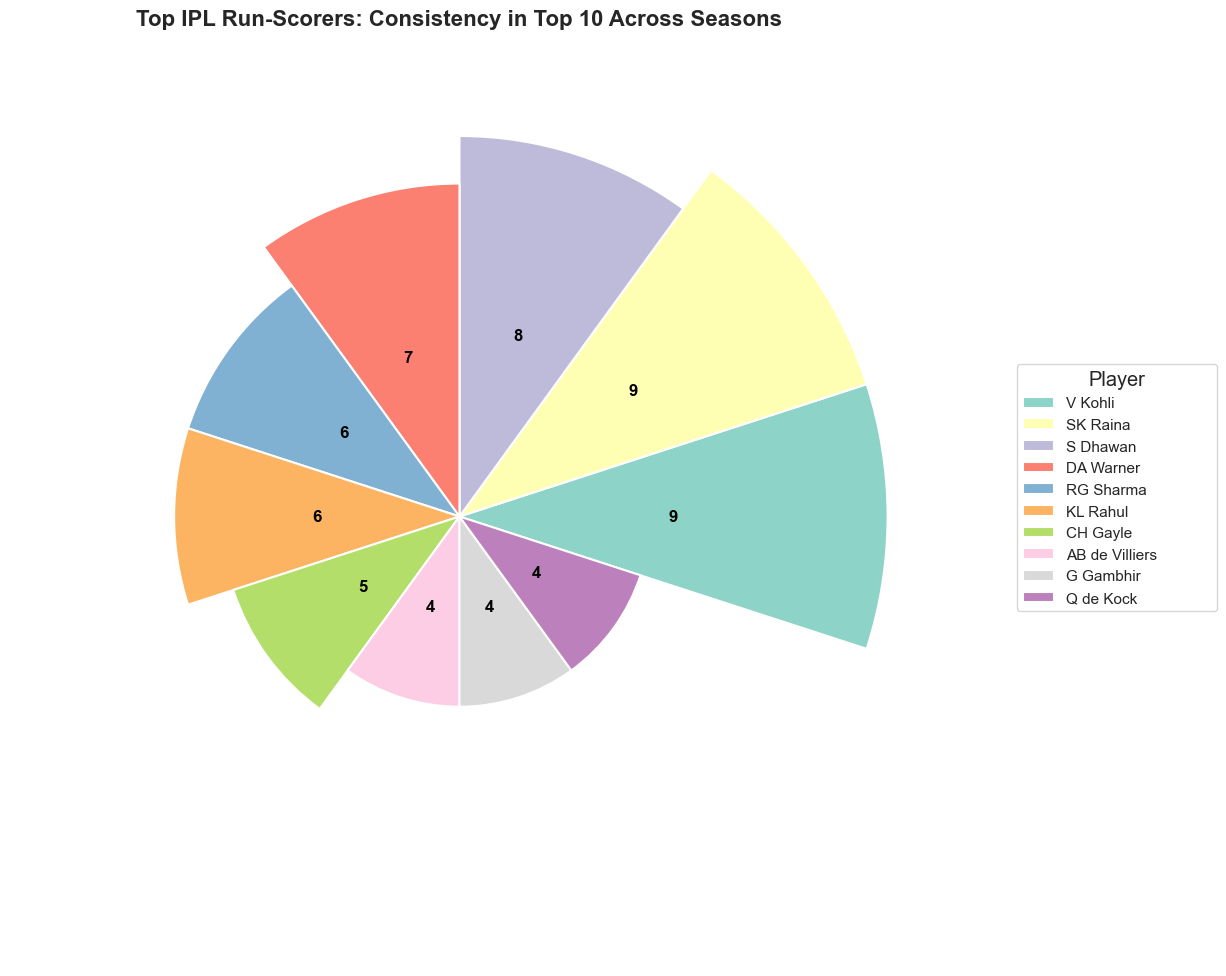

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

history_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Ipl20.csv")
matches_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")

history_df.columns = history_df.columns.str.strip()
matches_df.columns = matches_df.columns.str.strip()
matches_df['date'] = pd.to_datetime(matches_df['date'], errors='coerce')

merged_df = pd.merge(history_df, matches_df[['id', 'date']], left_on='match_id', right_on='id', how='left')
merged_df['Year'] = merged_df['date'].dt.year

runs_per_season = merged_df.groupby(['Year', 'batter'])['batsman_runs'].sum().reset_index()
top_scorers = runs_per_season.sort_values(['Year', 'batsman_runs'], ascending=[True, False])
top_10_each_season = top_scorers.groupby('Year').head(10)

consistency = top_10_each_season['batter'].value_counts().reset_index()
consistency.columns = ['batter', 'seasons_in_top10']
consistency = consistency.head(10)

top_n = 10
players = consistency['batter'].tolist()
values = consistency['seasons_in_top10'].tolist()

angles = np.linspace(0, 2 * np.pi, top_n, endpoint=False).tolist()
bar_width = 2 * np.pi / top_n

colors = plt.get_cmap('Set3').colors[:top_n]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'polar': True})
ax.set_facecolor('white')

bars = ax.bar(angles, values, width=bar_width, color=colors, edgecolor='white', linewidth=1.5)

for angle, height in zip(angles, values):
    ax.text(angle, height / 2, str(height), ha='center', va='center', fontsize=12, fontweight='bold', color='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines['polar'].set_visible(False)

legend_labels = [f"{p}" for p in players]
fig.legend(bars, legend_labels, loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=11, title="Player")

ax.set_title("Top IPL Run-Scorers: Consistency in Top 10 Across Seasons", fontsize=16, fontweight='bold', pad=30)

plt.tight_layout()
plt.show()


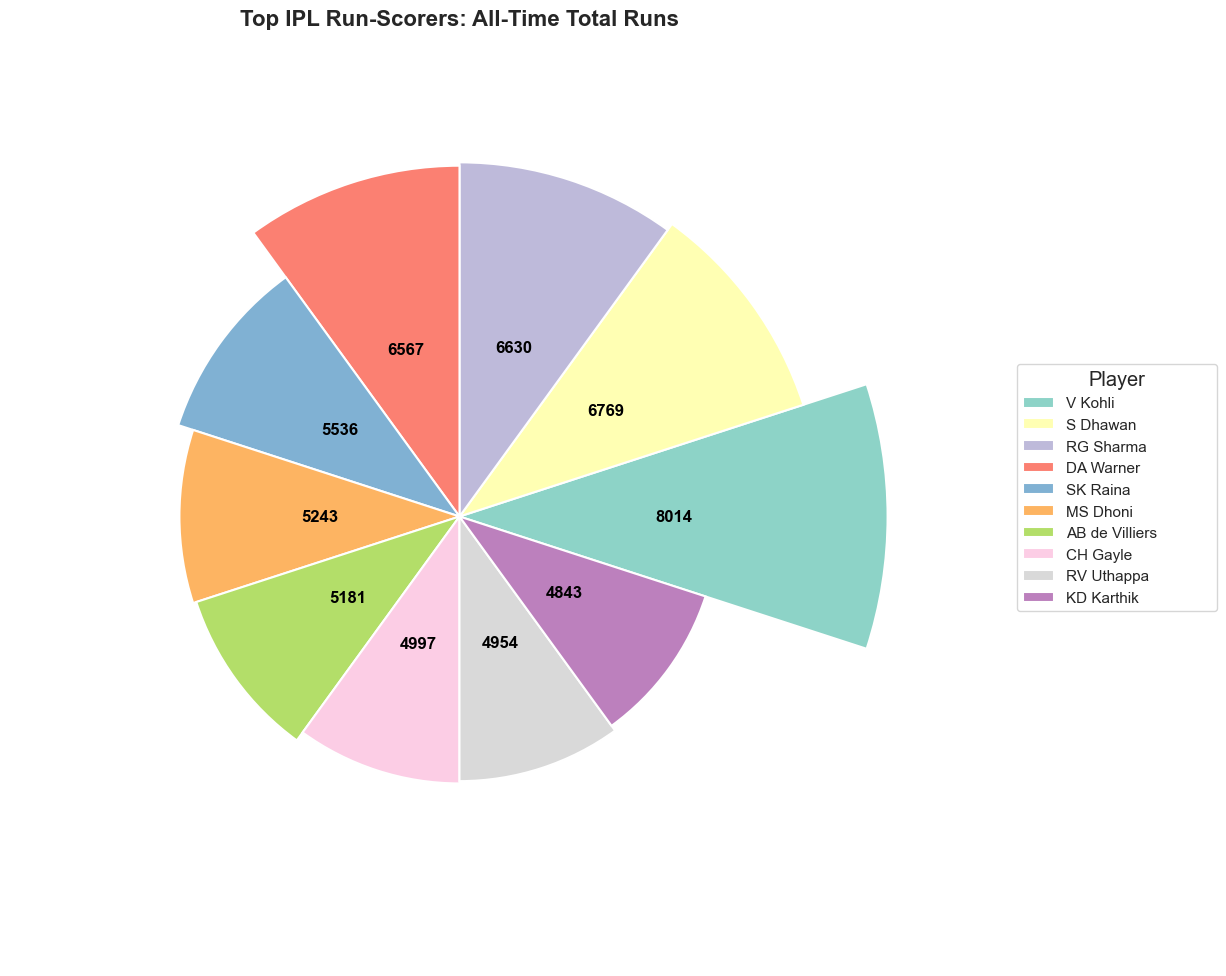

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

history_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Ipl20.csv")
matches_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")

history_df.columns = history_df.columns.str.strip()
matches_df.columns = matches_df.columns.str.strip()
matches_df['date'] = pd.to_datetime(matches_df['date'], errors='coerce')

merged_df = pd.merge(history_df, matches_df[['id', 'date']], left_on='match_id', right_on='id', how='left')
merged_df['Year'] = merged_df['date'].dt.year

overall_runs = merged_df.groupby('batter')['batsman_runs'].sum().reset_index()
top_scorers = overall_runs.sort_values(by='batsman_runs', ascending=False).head(10)

top_n = 10
players = top_scorers['batter'].tolist()
values = top_scorers['batsman_runs'].tolist()

angles = np.linspace(0, 2 * np.pi, top_n, endpoint=False).tolist()
bar_width = 2 * np.pi / top_n

colors = plt.get_cmap('Set3').colors[:top_n]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'polar': True})
ax.set_facecolor('white')

bars = ax.bar(angles, values, width=bar_width, color=colors, edgecolor='white', linewidth=1.5)

for angle, height in zip(angles, values):
    ax.text(angle, height / 2, str(height), ha='center', va='center', fontsize=12, fontweight='bold', color='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines['polar'].set_visible(False)

legend_labels = [f"{p}" for p in players]
fig.legend(bars, legend_labels, loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=11, title="Player")

ax.set_title("Top IPL Run-Scorers: All-Time Total Runs", fontsize=16, fontweight='bold', pad=30)

plt.tight_layout()
plt.show()


In [122]:
import pandas as pd


history_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Ipl20.csv")
matches_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")


history_df.columns = history_df.columns.str.strip()
matches_df.columns = matches_df.columns.str.strip()
matches_df['date'] = pd.to_datetime(matches_df['date'], errors='coerce')


merged_df = pd.merge(history_df, matches_df[['id', 'date']], left_on='match_id', right_on='id', how='left')
merged_df['Year'] = merged_df['date'].dt.year


runs_per_season = merged_df.groupby(['Year', 'batter'])['batsman_runs'].sum().reset_index()
top_10_each_season = runs_per_season.sort_values(['Year', 'batsman_runs'], ascending=[True, False]).groupby('Year').head(10)


consistent_players = top_10_each_season['batter'].str.strip().value_counts().head(10).index.tolist()


overall_runs = merged_df.groupby('batter')['batsman_runs'].sum().reset_index()
overall_runs['batter'] = overall_runs['batter'].str.strip()
top_scorers = overall_runs.sort_values(by='batsman_runs', ascending=False).head(10)
top_scorers_list = top_scorers['batter'].tolist()


common_players = [player for player in top_scorers_list if player in consistent_players]

print("Common players in both charts (ordered by total runs):")
for player in common_players:
    print(player)



Common players in both charts (ordered by total runs):
V Kohli
S Dhawan
RG Sharma
DA Warner
SK Raina
AB de Villiers
CH Gayle


## 👑 IPL’s Most Consistent Run-Scorers

The players below are not just top run-getters—they've displayed remarkable consistency across multiple IPL seasons. Regardless of their team’s fate, these batters have delivered season after season:

- **Virat Kohli**
- **Shikhar Dhawan**
- **Rohit Sharma**
- **David Warner**
- **Suresh Raina**
- **AB de Villiers**
- **Chris Gayle**



## 🎯 Wicket-Taking Machines – Do Bowlers Win You Titles?

While batters get the limelight, many IPL titles have been won by bowling brilliance. This section explores how consistent top-performing bowlers influence team success.

> A **Violin Plot** visualizes the distribution of wickets per season for key players, showing the spread and density of bowling performances.


In [126]:
import pandas as pd

# ✅ Step 1: Load and clean data
ipl_data = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Ipl20.csv")
matches_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")

ipl_data.columns = ipl_data.columns.str.strip()
matches_df.columns = matches_df.columns.str.strip()

# ✅ Step 2: Parse date and extract season year
matches_df['date'] = pd.to_datetime(matches_df['date'], errors='coerce')
matches_df['season_year'] = matches_df['date'].dt.year

# ✅ Step 3: Merge season info into IPL data
ipl_data = pd.merge(
    ipl_data,
    matches_df[['id', 'season_year']],
    left_on='match_id',
    right_on='id',
    how='left'
)

# ✅ Step 4: Filter valid wicket events (exclude run outs)
valid_wickets = ipl_data[
    (ipl_data['is_wicket'] == 1) &
    (~ipl_data['dismissal_kind'].str.lower().fillna('').str.contains('run out'))
]

# ✅ Step 5: Wickets per bowler per season and their team
bowler_team_season = valid_wickets.groupby(
    ['bowler', 'season_year', 'bowling_team']
)['is_wicket'].count().reset_index(name='wickets')

# ✅ Step 6: Identify season winners from the final match of each season
season_winners = matches_df.sort_values('date').groupby('season_year').tail(1)[['season_year', 'winner']]
season_winners = season_winners.rename(columns={'winner': 'season_winner'})

# ✅ Step 7: Merge winner info
bowler_team_season = bowler_team_season.merge(season_winners, on='season_year', how='left')

# ✅ Step 8: Flag if bowler's team won that season
bowler_team_season['won_title'] = bowler_team_season['bowling_team'] == bowler_team_season['season_winner']

# ✅ Step 9: Identify top 10 bowlers overall
top_bowlers = bowler_team_season.groupby('bowler')['wickets'].sum().nlargest(10).index
top_bowler_data = bowler_team_season[bowler_team_season['bowler'].isin(top_bowlers)]

# ✅ Step 10: Summarize title-winning impact
bowler_impact_summary = top_bowler_data.groupby('bowler').agg(
    seasons_played=('season_year', 'nunique'),
    title_winning_seasons=('won_title', 'sum'),
    total_wickets=('wickets', 'sum')
).reset_index()

# ✅ Output the summary
print(bowler_impact_summary)


                     bowler  seasons_played  title_winning_seasons  \
0  A Mishra                              16                      0   
1  B Kumar                               14                      1   
2  DJ Bravo                              13                      3   
3  JJ Bumrah                             11                      5   
4  PP Chawla                             16                      1   
5  R Ashwin                              15                      2   
6  RA Jadeja                             15                      3   
7  SL Malinga                             9                      4   
8  SP Narine                             13                      3   
9  YS Chahal                             11                      0   

   total_wickets  
0            174  
1            181  
2            183  
3            168  
4            192  
5            181  
6            160  
7            170  
8            180  
9            205  


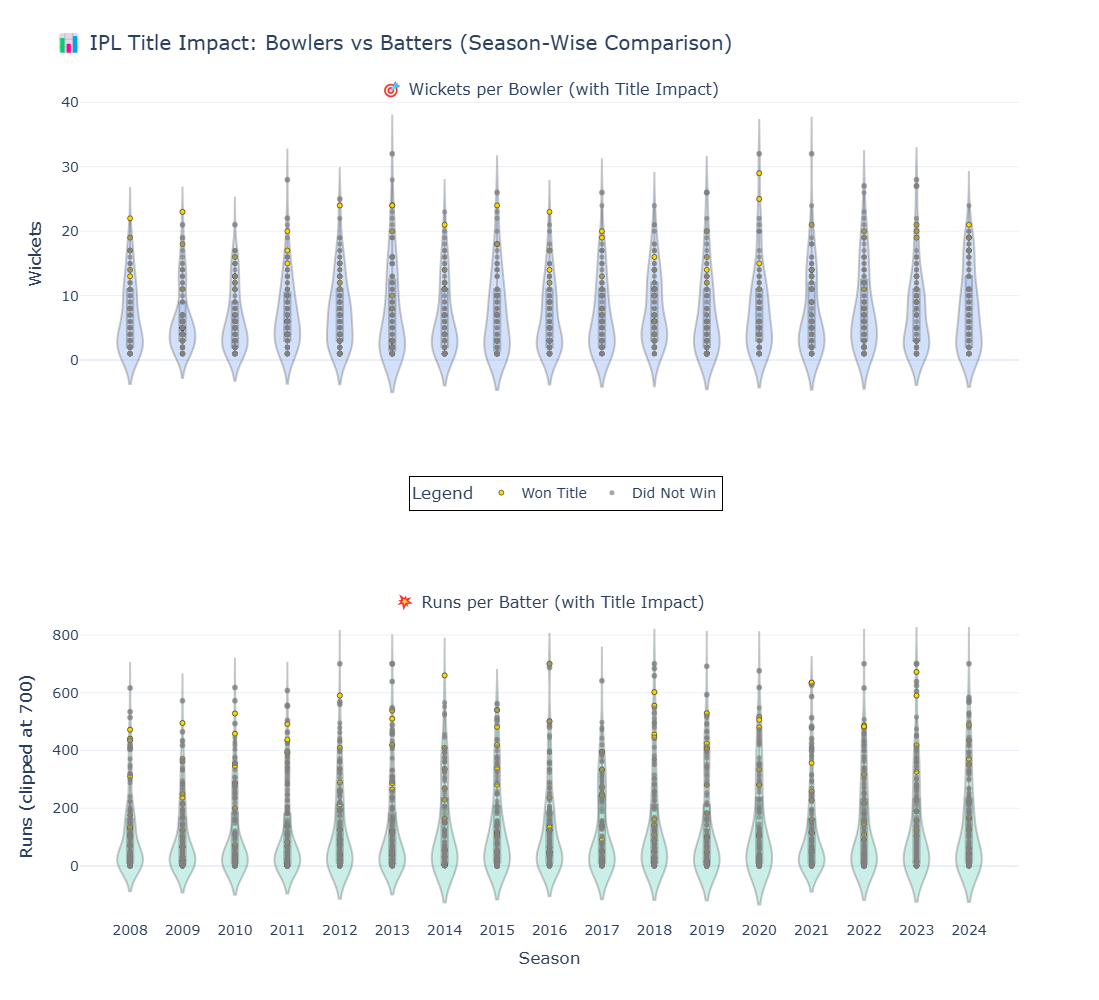

In [135]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ✅ Step 1: Load and clean data
ipl_data = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Ipl20.csv")
matches_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")

ipl_data.columns = ipl_data.columns.str.strip()
matches_df.columns = matches_df.columns.str.strip()

# ✅ Step 2: Parse date and extract season year
matches_df['date'] = pd.to_datetime(matches_df['date'], errors='coerce')
matches_df['season_year'] = matches_df['date'].dt.year

# ✅ Step 3: Merge season info into IPL data
ipl_data = pd.merge(
    ipl_data,
    matches_df[['id', 'season_year']],
    left_on='match_id',
    right_on='id',
    how='left'
)

# ✅ Step 4: Filter valid wicket events (exclude run outs)
valid_wickets = ipl_data[
    (ipl_data['is_wicket'] == 1) &
    (~ipl_data['dismissal_kind'].str.lower().fillna('').str.contains('run out'))
]

# ✅ Step 5: Wickets per bowler per season and their team
bowler_season_team = valid_wickets.groupby(
    ['bowler', 'season_year', 'bowling_team']
)['is_wicket'].count().reset_index(name='wickets')

# ✅ Step 6: Runs per batter per season and team
batter_season_team = ipl_data.groupby(
    ['batter', 'season_year', 'batting_team']
)['batsman_runs'].sum().reset_index(name='runs')

# ✅ Step 7: Identify season winners
season_winners = matches_df.sort_values('date').groupby('season_year').tail(1)[['season_year', 'winner']]
season_winners = season_winners.rename(columns={'winner': 'season_winner'})

# ✅ Step 8: Merge winner info
bowler_season_team = bowler_season_team.merge(season_winners, on='season_year', how='left')
batter_season_team = batter_season_team.merge(season_winners, on='season_year', how='left')

# ✅ Step 9: Flag title winners
bowler_season_team['won_title'] = bowler_season_team['bowling_team'] == bowler_season_team['season_winner']
batter_season_team['won_title'] = batter_season_team['batting_team'] == batter_season_team['season_winner']

# ✅ Step 10: Clean columns for plotting
bowler_season_team = bowler_season_team.rename(columns={'season_year': 'season'})
batter_season_team = batter_season_team.rename(columns={'season_year': 'season'})

# Clip extreme batting runs to improve visual distribution
batter_season_team['runs'] = batter_season_team['runs'].clip(upper=700)

# Ensure season is string for plotting
bowler_season_team['season'] = bowler_season_team['season'].astype(str)
batter_season_team['season'] = batter_season_team['season'].astype(str)

# Split winner and non-winner rows
winners_bowl = bowler_season_team[bowler_season_team['won_title']]
others_bowl = bowler_season_team[~bowler_season_team['won_title']]
winners_bat = batter_season_team[batter_season_team['won_title']]
others_bat = batter_season_team[~batter_season_team['won_title']]

# Create subplot layout
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=("🎯 Wickets per Bowler (with Title Impact)", "💥 Runs per Batter (with Title Impact)")
)

# BOWLERS: violins + dots
for season in sorted(bowler_season_team['season'].unique()):
    sdata = bowler_season_team[bowler_season_team['season'] == season]
    fig.add_trace(go.Violin(
        x=sdata['season'], y=sdata['wickets'],
        box_visible=True, meanline_visible=True,
        line_color='rgba(0,0,0,0.3)', fillcolor='rgba(100,149,237,0.4)',
        opacity=0.7, scalemode='count', showlegend=False
    ), row=1, col=1)

fig.add_trace(go.Scatter(
    x=winners_bowl['season'], y=winners_bowl['wickets'],
    mode='markers', name='Won Title',
    marker=dict(color='gold', size=5, line=dict(color='black', width=0.5)),
    text=[f"{r.bowler}<br>{r.bowling_team}<br>{r.wickets} wickets" for _, r in winners_bowl.iterrows()],
    hoverinfo='text'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=others_bowl['season'], y=others_bowl['wickets'],
    mode='markers', name='Did Not Win',
    marker=dict(color='gray', size=5, opacity=0.7),
    text=[f"{r.bowler}<br>{r.bowling_team}<br>{r.wickets} wickets" for _, r in others_bowl.iterrows()],
    hoverinfo='text'
), row=1, col=1)

# BATTERS: violins + dots
for season in sorted(batter_season_team['season'].unique()):
    sdata = batter_season_team[batter_season_team['season'] == season]
    fig.add_trace(go.Violin(
        x=sdata['season'], y=sdata['runs'],
        box_visible=True, meanline_visible=True,
        line_color='rgba(0,0,0,0.3)', fillcolor='rgba(72,201,176,0.4)',
        opacity=0.7, scalemode='width', showlegend=False
    ), row=2, col=1)

fig.add_trace(go.Scatter(
    x=winners_bat['season'], y=winners_bat['runs'],
    mode='markers', name='Won Title',
    marker=dict(color='gold', size=5, line=dict(color='black', width=0.5)),
    text=[f"{r.batter}<br>{r.batting_team}<br>{r.runs} runs" for _, r in winners_bat.iterrows()],
    hoverinfo='text', showlegend=False
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=others_bat['season'], y=others_bat['runs'],
    mode='markers', name='Did Not Win',
    marker=dict(color='gray', size=5, opacity=0.7),
    text=[f"{r.batter}<br>{r.batting_team}<br>{r.runs} runs" for _, r in others_bat.iterrows()],
    hoverinfo='text', showlegend=False
), row=2, col=1)

# Final layout
fig.update_layout(
    height=1000,
    width=1200,
    title="📊 IPL Title Impact: Bowlers vs Batters (Season-Wise Comparison)",
    font=dict(size=14),
    violinmode='overlay',
    template='plotly_white',
    legend=dict(
        title='Legend',
        orientation='h',
        x=0.35,
        y=0.52,
        xanchor='left',
        yanchor='middle',
        bgcolor='rgba(255,255,255,0.7)',
        bordercolor='black',
        borderwidth=1
    )
)

# Axis labels
fig.update_yaxes(title_text="Wickets", row=1, col=1)
fig.update_yaxes(title_text="Runs (clipped at 700)", row=2, col=1)
fig.update_xaxes(title_text="Season", row=2, col=1)

# Show plot
fig.show()

## 🧊 Playoff Magic – Heroes or Chokers?

Playoffs are the ultimate test of nerve. This section compares league-stage performance with playoff outcomes to determine who shines—and who stumbles—under pressure.

> A **Box Plot** contrasts league-stage and playoff win percentages.


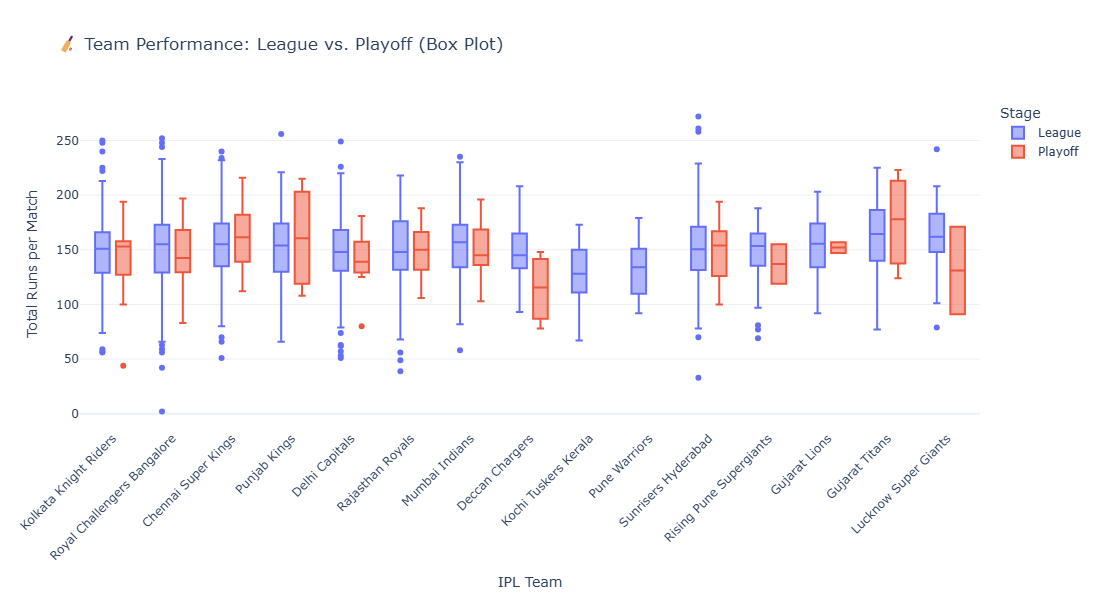

In [139]:
import pandas as pd
import plotly.express as px

# ✅ Load cleaned data
matches_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")
history_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Ipl20.csv")

# ✅ Clean column names
matches_df.columns = matches_df.columns.str.strip()
history_df.columns = history_df.columns.str.strip()

# ✅ Standardize team names
team_name_mapping = {
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Rising Pune Supergiants': 'Rising Pune Supergiants'
}

history_df['batting_team'] = history_df['batting_team'].str.strip().replace(team_name_mapping)

# ✅ Classify match stage
matches_df['Stage'] = matches_df['match_type'].apply(
    lambda x: 'League' if str(x).strip().lower() == 'league' else 'Playoff'
)

# ✅ Aggregate team runs per match
team_runs = history_df.groupby(['match_id', 'batting_team'])['batsman_runs'].sum().reset_index()
team_runs = team_runs.rename(columns={'batting_team': 'Team', 'batsman_runs': 'Runs'})

# ✅ Merge with match stage
merged_df = pd.merge(team_runs, matches_df[['id', 'Stage']], left_on='match_id', right_on='id')

# ✅ Plot interactive box plot
fig = px.box(
    merged_df,
    x="Team",
    y="Runs",
    color="Stage",
    title="🏏 Team Performance: League vs. Playoff (Box Plot)",
    labels={"Runs": "Total Runs per Match", "Team": "IPL Team"},
    template="plotly_white",
    height=600
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()


## 📊 Performance vs Popularity

### 🔹 Scatter Plot with Trendline  
Shows if winning more matches leads to a bigger fan base. Trendline highlights correlation between team success and popularity.

### 🔹 Bubble Chart  
Visualizes team performance vs. fan growth. Bubble size shows brand impact—helps spot popular underdogs or dominant fan-favorite teams.


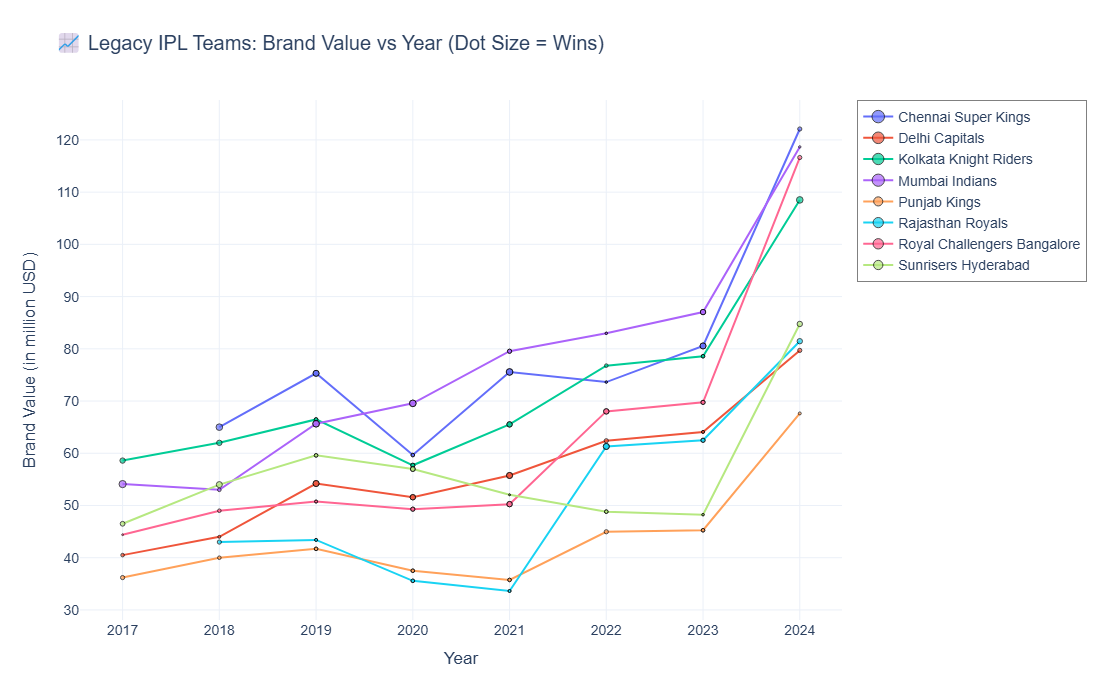

In [142]:
import pandas as pd
import plotly.graph_objects as go

# Load data
matches_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")
brand_long_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\cleaned_brand_value_long_format.csv")

# Clean and merge
matches_df.columns = matches_df.columns.str.strip()
matches_df['winner'] = matches_df['winner'].str.strip()
matches_df['date'] = pd.to_datetime(matches_df['date'], errors='coerce')
matches_df['Year'] = matches_df['date'].dt.year
valid_matches = matches_df.dropna(subset=['winner'])
wins = valid_matches.groupby(['winner', 'Year']).size().reset_index(name='Wins')
wins = wins.rename(columns={'winner': 'Team'})
merged = pd.merge(wins, brand_long_df, on=['Team', 'Year'])

# Filter legacy teams (excluding Gujarat Titans)
legacy_teams = merged['Team'].value_counts()[merged['Team'].value_counts() >= 5].index
legacy_teams = legacy_teams.difference(['Gujarat Titans'])
legacy_df = merged[merged['Team'].isin(legacy_teams)].copy()

# Create figure
fig = go.Figure()

for team in legacy_df['Team'].unique():
    team_data = legacy_df[legacy_df['Team'] == team].copy()
    win_sizes = team_data['Wins'] * 1.5  # Scale dot size

    fig.add_trace(go.Scatter(
        x=team_data['Year'],
        y=team_data['BrandValue'],
        mode='lines+markers',
        name=team,
        marker=dict(
            size=win_sizes.tolist(),
            sizemode='diameter',
            sizeref=2.5,
            line=dict(width=1, color='black')
        ),
        text=team_data['Team'],
        customdata=team_data['Wins'],
        hovertemplate=(
            "<b>%{text}</b><br>" +
            "Year: %{x}<br>" +
            "Brand Value: %{y}M<br>" +
            "Wins: %{customdata}<br>" +
            "<i>(Team: %{text})</i>"
        )
    ))

# Layout tweaks
fig.update_layout(
    title="📈 Legacy IPL Teams: Brand Value vs Year (Dot Size = Wins)",
    xaxis_title="Year",
    yaxis_title="Brand Value (in million USD)",
    template="plotly_white",
    width=1200,
    height=700,
    font=dict(family="Helvetica", size=14),
    xaxis=dict(tickmode='linear', dtick=1),
    legend=dict(bordercolor="gray", borderwidth=1)
)

fig.show()


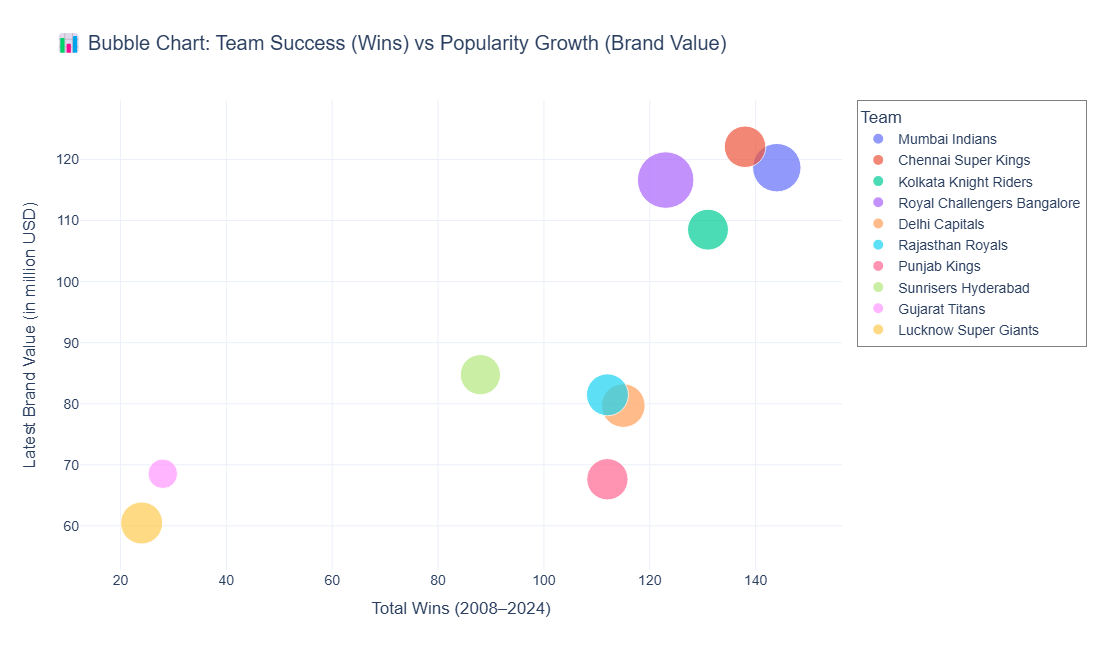

In [144]:
import pandas as pd
import plotly.express as px

# Load data
matches_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")
brand_long_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\cleaned_brand_value_long_format.csv")

# Clean matches data
matches_df.columns = matches_df.columns.str.strip()
matches_df['winner'] = matches_df['winner'].str.strip()

# Count total wins per team
total_wins = matches_df['winner'].value_counts().reset_index()
total_wins.columns = ['Team', 'TotalWins']

# Clean brand value data
brand_df = brand_long_df.copy()
brand_df = brand_df.sort_values(by=['Team', 'Year'])

# Calculate popularity growth: (latest - earliest) / earliest * 100
growth_df = brand_df.groupby('Team').agg(
    FirstYearValue=('BrandValue', 'first'),
    LastYearValue=('BrandValue', 'last')
).reset_index()
growth_df['GrowthPercent'] = ((growth_df['LastYearValue'] - growth_df['FirstYearValue']) / growth_df['FirstYearValue']) * 100
growth_df = growth_df[growth_df['FirstYearValue'] > 0]  # avoid divide-by-zero

# Merge wins with brand growth
bubble_df = pd.merge(total_wins, growth_df, on='Team', how='inner')

# Plot
fig = px.scatter(
    bubble_df,
    x="TotalWins",
    y="LastYearValue",
    size="GrowthPercent",
    color="Team",
    hover_data=["Team", "TotalWins", "GrowthPercent", "LastYearValue"],
    title="📊 Bubble Chart: Team Success (Wins) vs Popularity Growth (Brand Value)",
    size_max=40,
    template="plotly_white"
)

fig.update_layout(
    xaxis_title="Total Wins (2008–2024)",
    yaxis_title="Latest Brand Value (in million USD)",
    font=dict(family="Helvetica", size=14),
    legend=dict(bordercolor="gray", borderwidth=1),
    width=1100,
    height=650
)

fig.show()


## 🔥 One-Sided Rivalries – Heatmap

This heatmap highlights **one-sided matchups** in IPL history, showing teams that consistently dominate or struggle against specific opponents.  
Darker cells indicate higher win margins or frequent losses, revealing intense rivalries and persistent underperformance patterns.


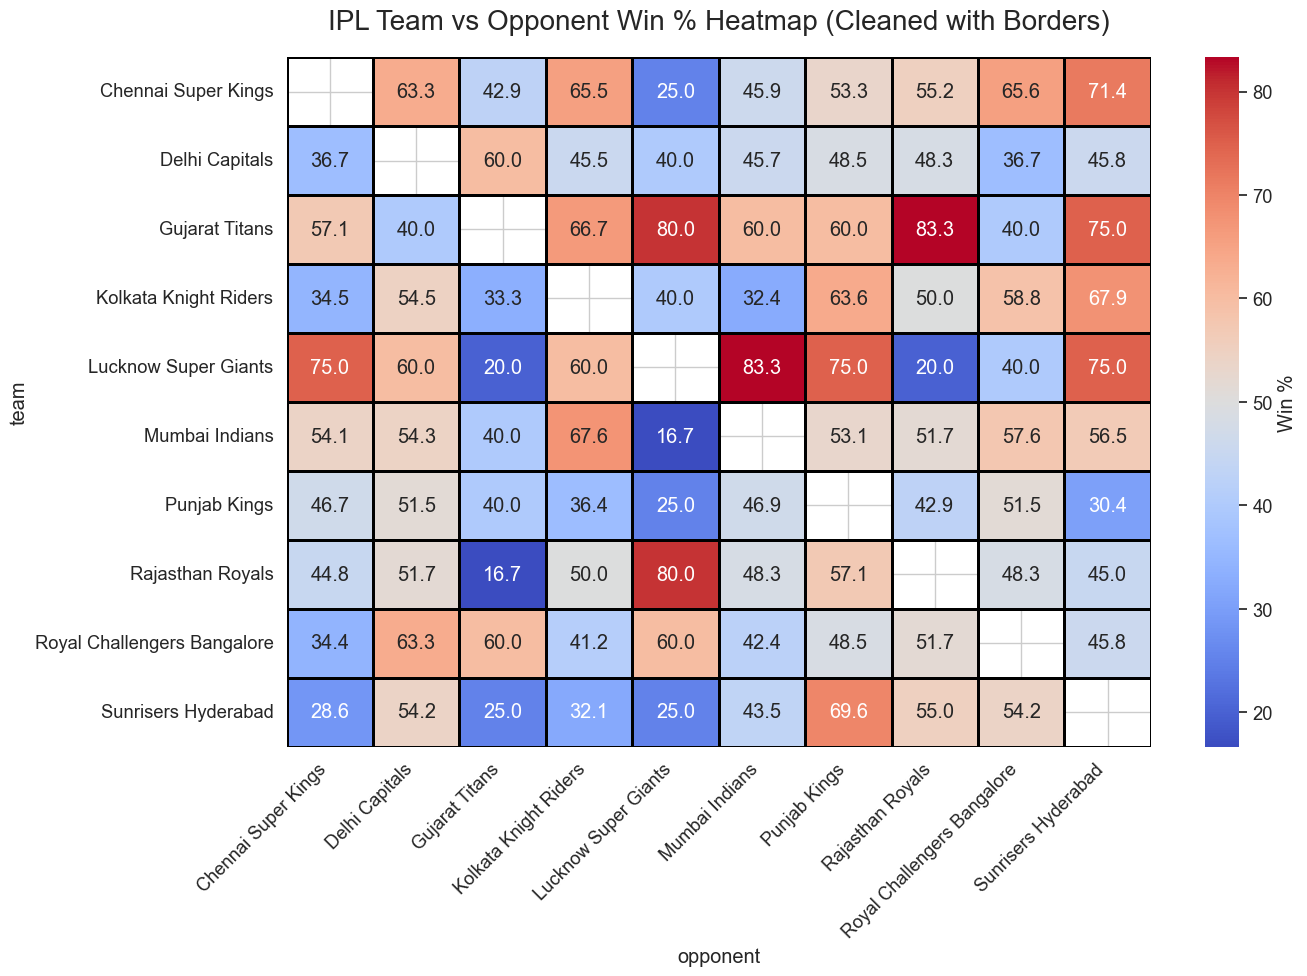

In [147]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load matches dataset
matches = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")
matches.columns = matches.columns.str.strip()

# Step 2: Standardize Team Names
team_name_corrections = {
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Royal Challengers Bangalore': 'Royal Challengers Bangalore',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Rising Pune Supergiant': 'Rising Pune Supergiant'
}

for col in ['team1', 'team2', 'winner']:
    matches[col] = matches[col].replace(team_name_corrections)

# Step 3: Prepare Data
matches = matches[matches['winner'].notna()]

# Step 4: Create win records
data = []

for idx, row in matches.iterrows():
    team1 = row['team1']
    team2 = row['team2']
    winner = row['winner']

    if team1 != team2:  # Ignore same-team
        data.append({'team': team1, 'opponent': team2, 'won': int(winner == team1)})
        data.append({'team': team2, 'opponent': team1, 'won': int(winner == team2)})

df = pd.DataFrame(data)

# Step 5: Group by team and opponent
team_vs_opponent = df.groupby(['team', 'opponent']).agg(
    matches_played=('won', 'count'),
    matches_won=('won', 'sum')
).reset_index()

team_vs_opponent['win_percentage'] = (team_vs_opponent['matches_won'] / team_vs_opponent['matches_played']) * 100

# Step 6: Pivot
heatmap_data = team_vs_opponent.pivot(index='team', columns='opponent', values='win_percentage')

# Step 7: Mask Diagonal (team vs itself)
mask = heatmap_data.copy()
for team in heatmap_data.index:
    if team in heatmap_data.columns:
        mask.loc[team, team] = np.nan

# Optional: Remove Old Defunct Teams
defunct_teams = ['Deccan Chargers', 'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiant', 'Gujarat Lions']
mask = mask.drop(index=defunct_teams, errors='ignore')
mask = mask.drop(columns=defunct_teams, errors='ignore')

# Step 8: Plot Clean Heatmap WITH BORDERS
plt.figure(figsize=(14, 10))
sns.heatmap(
    mask, 
    annot=True, 
    fmt=".1f", 
    cmap='coolwarm', 
    linewidths=1.0,  # ✅ thick borders
    linecolor='black',  # ✅ black borders
    cbar_kws={'label': 'Win %'}, 
    mask=mask.isnull()
)
plt.title('IPL Team vs Opponent Win % Heatmap (Cleaned with Borders)', fontsize=20, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


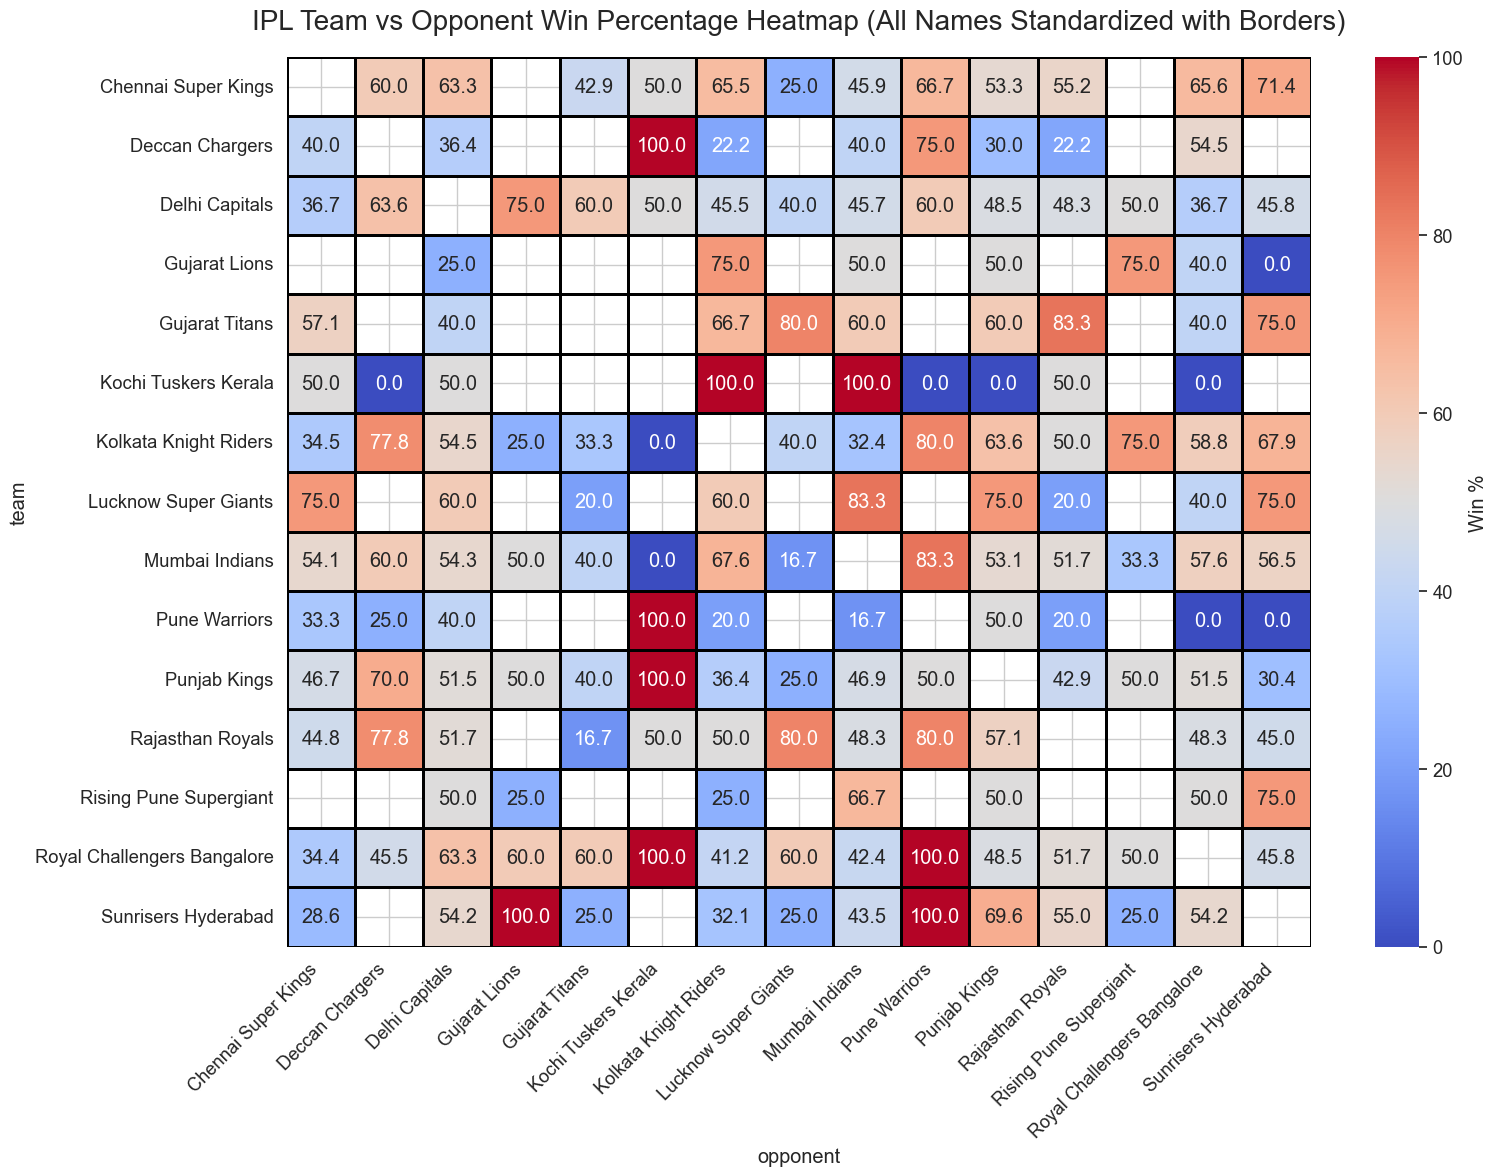

In [149]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load matches dataset
matches = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")
matches.columns = matches.columns.str.strip()

# Step 2: Standardize Team Names
team_name_corrections = {
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Royal Challengers Bangalore': 'Royal Challengers Bangalore',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Rising Pune Supergiant': 'Rising Pune Supergiant'
}

for col in ['team1', 'team2', 'winner']:
    matches[col] = matches[col].replace(team_name_corrections)

# Step 3: Prepare Data
matches = matches[matches['winner'].notna()]

# Step 4: Create win records
data = []

for idx, row in matches.iterrows():
    team1 = row['team1']
    team2 = row['team2']
    winner = row['winner']

    if team1 != team2:  # Ignore ties if any
        data.append({'team': team1, 'opponent': team2, 'won': int(winner == team1)})
        data.append({'team': team2, 'opponent': team1, 'won': int(winner == team2)})

df = pd.DataFrame(data)

# Step 5: Group by team and opponent
team_vs_opponent = df.groupby(['team', 'opponent']).agg(
    matches_played=('won', 'count'),
    matches_won=('won', 'sum')
).reset_index()

# Step 6: Calculate Win Percentage
team_vs_opponent['win_percentage'] = (team_vs_opponent['matches_won'] / team_vs_opponent['matches_played']) * 100

# Step 7: Pivot for Heatmap
heatmap_data = team_vs_opponent.pivot(index='team', columns='opponent', values='win_percentage')

# Step 8: Plot Heatmap with Borders
plt.figure(figsize=(16, 12))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap='coolwarm',
    linewidths=1.0,   # ✅ thicker lines
    linecolor='black', # ✅ black borders
    cbar_kws={'label': 'Win %'}
)
plt.title('IPL Team vs Opponent Win Percentage Heatmap (All Names Standardized with Borders)', fontsize=20, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


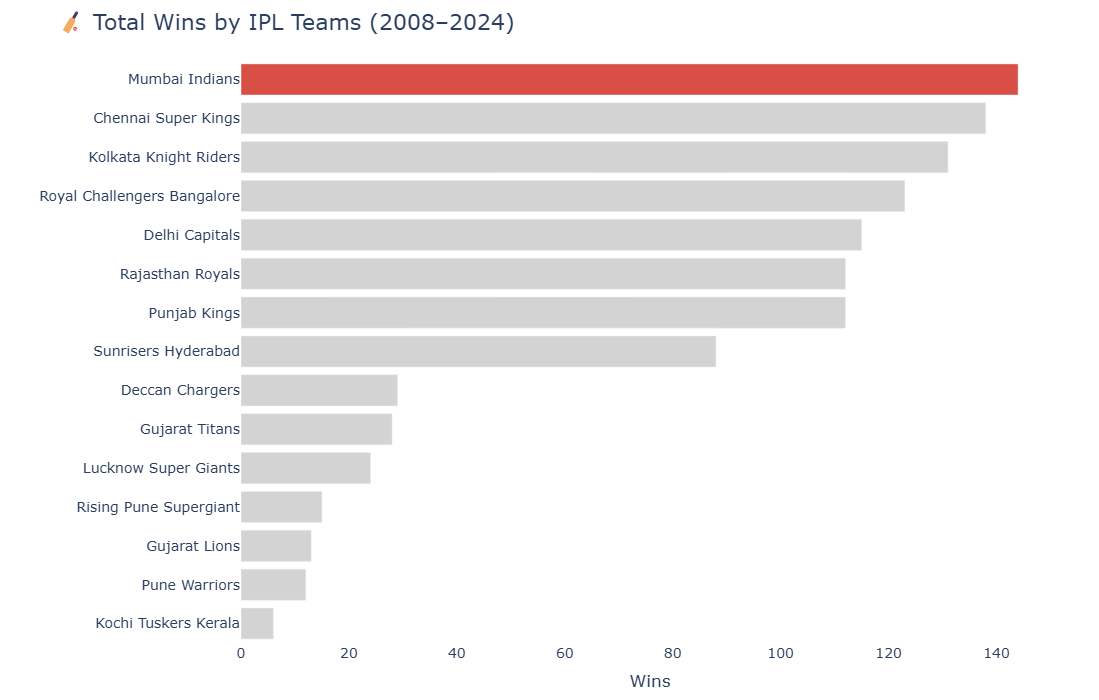

In [153]:
import pandas as pd
import plotly.express as px

# Load and clean match data
matches = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")
matches.columns = matches.columns.str.strip()

# Standardize team names
team_name_corrections = {
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Royal Challengers Bangalore': 'Royal Challengers Bangalore',
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Rising Pune Supergiant': 'Rising Pune Supergiant'
}
for col in ['team1', 'team2', 'winner']:
    matches[col] = matches[col].replace(team_name_corrections)

# Total wins and matches played
wins = matches['winner'].value_counts().reset_index()
wins.columns = ['team', 'wins']
team1_counts = matches['team1'].value_counts()
team2_counts = matches['team2'].value_counts()
matches_played = (team1_counts + team2_counts).reset_index()
matches_played.columns = ['team', 'matches_played']

# Merge and calculate win percentage
performance = pd.merge(wins, matches_played, on='team', how='outer').fillna(0)
performance['win_percentage'] = (performance['wins'] / performance['matches_played']) * 100
performance = performance.sort_values(by="wins", ascending=True)

# Highlight top team
highlight_team = performance.iloc[-1]['team']
performance['color'] = performance['team'].apply(
    lambda x: '#d94f45' if x == highlight_team else 'lightgray'
)

# Plot without numbers on bar heads
fig = px.bar(
    performance,
    x='wins',
    y='team',
    orientation='h',
    title='🏏 Total Wins by IPL Teams (2008–2024)',
)

fig.update_traces(
    marker_color=performance['color']
)

fig.update_layout(
    height=700, width=900,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=14),
    title_font=dict(size=22),
    xaxis=dict(title='Wins', showgrid=False),
    yaxis=dict(title='', showgrid=False),
    margin=dict(l=150, r=40, t=60, b=40),
    showlegend=False
)

fig.show()


C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\LENOVO\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the

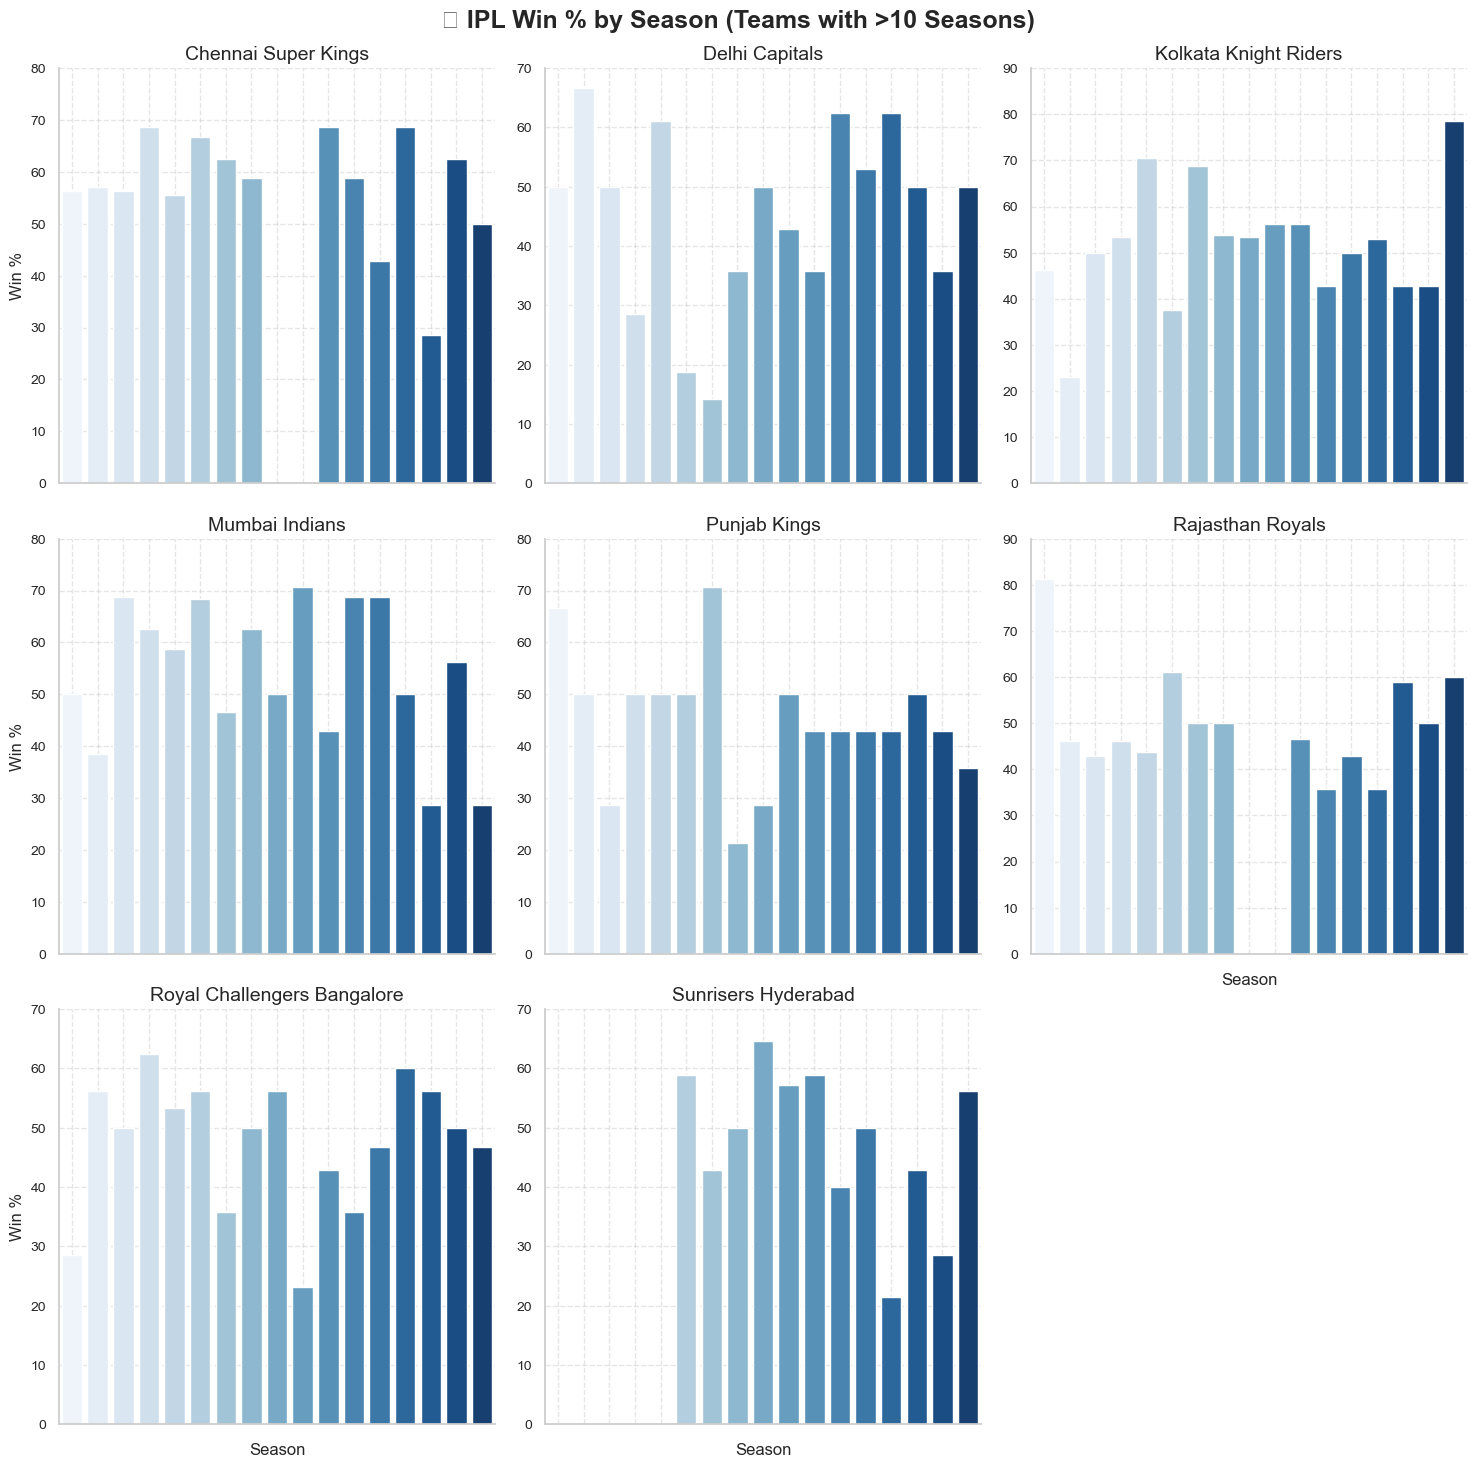

In [155]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reload data
matches_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")
matches_df.columns = matches_df.columns.str.strip()

# Long format for team appearances
long_df = pd.melt(
    matches_df,
    id_vars=["season", "winner"],
    value_vars=["team1", "team2"],
    var_name="role",
    value_name="team"
)

# Matches played per team per season
matches_played = long_df.groupby(['season', 'team']).size().reset_index(name='Matches_Played')

# Wins per team per season
wins = matches_df.groupby(['season', 'winner']).size().reset_index(name='Wins')
wins = wins.rename(columns={'winner': 'team'})

# Merge and compute win percentage
team_stats = pd.merge(matches_played, wins, on=['season', 'team'], how='left').fillna(0)
team_stats['Win_Percent'] = (team_stats['Wins'] / team_stats['Matches_Played']) * 100
team_stats['season'] = team_stats['season'].astype(str).str.strip()

# Filter teams with more than 10 seasons
season_counts = team_stats.groupby('team')['season'].nunique().reset_index(name='Season_Count')
long_term_teams = season_counts[season_counts['Season_Count'] > 10]['team'].tolist()
filtered_stats = team_stats[team_stats['team'].isin(long_term_teams)]

# Set the style
sns.set(style="whitegrid", palette="muted", font_scale=1.2)

# Plot: Facet bar chart (one subplot per team)
g = sns.FacetGrid(filtered_stats, col="team", col_wrap=3, height=5, sharey=False)
g.map_dataframe(sns.barplot, x="season", y="Win_Percent", palette="Blues", order=sorted(filtered_stats['season'].unique()))

# Beautify the plot
g.set_titles("{col_name}", size=14)
g.set_axis_labels("Season", "Win %", size=12)
g.set_xticklabels(rotation=45, size=10)
g.set_yticklabels(size=10)

# Add gridlines and improve spacing
for ax in g.axes.flatten():
    ax.grid(True, linestyle='--', alpha=0.5)

# Title and adjustments
plt.subplots_adjust(top=0.9)
g.fig.suptitle("📊 IPL Win % by Season (Teams with >10 Seasons)", fontsize=18, weight='bold')
plt.tight_layout()

# Show plot
plt.show()


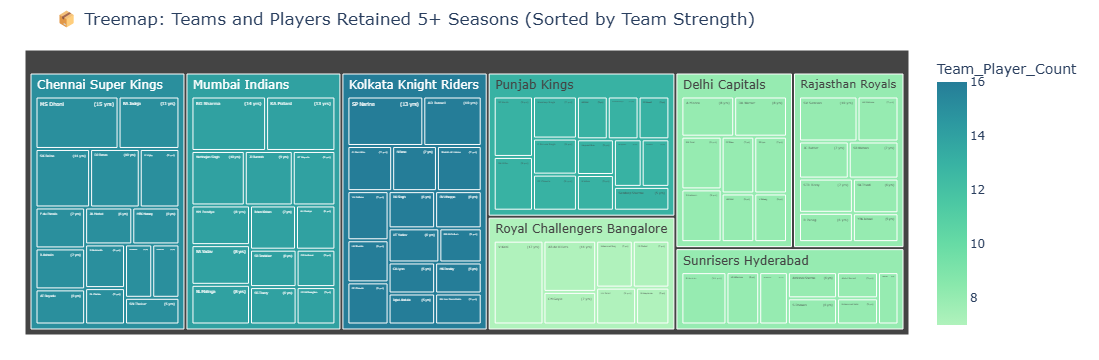

In [157]:
import pandas as pd
import plotly.express as px

# ✅ Load Data
matches_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")
history_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Ipl20.csv")

# ✅ Clean Columns
matches_df.columns = matches_df.columns.str.strip()
history_df.columns = history_df.columns.str.strip()

# ✅ Standardize team names
team_name_mapping = {
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils': 'Delhi Capitals',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Rising Pune Supergiants': 'Rising Pune Supergiants'
}
history_df['batting_team'] = history_df['batting_team'].str.strip().replace(team_name_mapping)

# ✅ Merge to get season info
history_with_season = pd.merge(
    history_df,
    matches_df[['id', 'season']],
    left_on='match_id',
    right_on='id',
    how='left'
)

# ✅ Focus on needed columns
history_with_season = history_with_season[['season', 'batting_team', 'batter']].dropna()
history_with_season['season'] = history_with_season['season'].astype(str).str.strip()

# ✅ Group players by team and seasons played
player_season_map = history_with_season.drop_duplicates().groupby(['batting_team', 'batter'])['season'].apply(set).reset_index()
player_season_map['num_seasons'] = player_season_map['season'].apply(len)

# ✅ Filter players who played at least 5 seasons for the same team
retained_5yr_plus = player_season_map[player_season_map['num_seasons'] >= 5]

# ✅ Calculate number of such players per team
team_retention_count = retained_5yr_plus.groupby('batting_team').size().reset_index(name='Players_5yr+')

# ✅ Merge back to add team player counts
treemap_data = retained_5yr_plus.merge(team_retention_count, on='batting_team')

# ✅ Rename for clarity
treemap_data.columns = ['Team', 'Player', 'Seasons', 'Num_Seasons', 'Team_Player_Count']

# ✅ Create combined label
treemap_data['Player_Label'] = treemap_data['Player'] + ' (' + treemap_data['Num_Seasons'].astype(str) + ' yrs)'

# ✅ Sort: first by number of players in team, then by player seniority
treemap_data = treemap_data.sort_values(by=['Team_Player_Count', 'Num_Seasons'], ascending=[False, False])

# ✅ Final Treemap
fig = px.treemap(
    treemap_data,
    path=['Team', 'Player_Label'],
    values='Num_Seasons',
    color='Team_Player_Count',
    color_continuous_scale='Tealgrn',
    title='📦 Treemap: Teams and Players Retained 5+ Seasons (Sorted by Team Strength)',
    template='plotly_white'
)

fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26708\3248597493.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



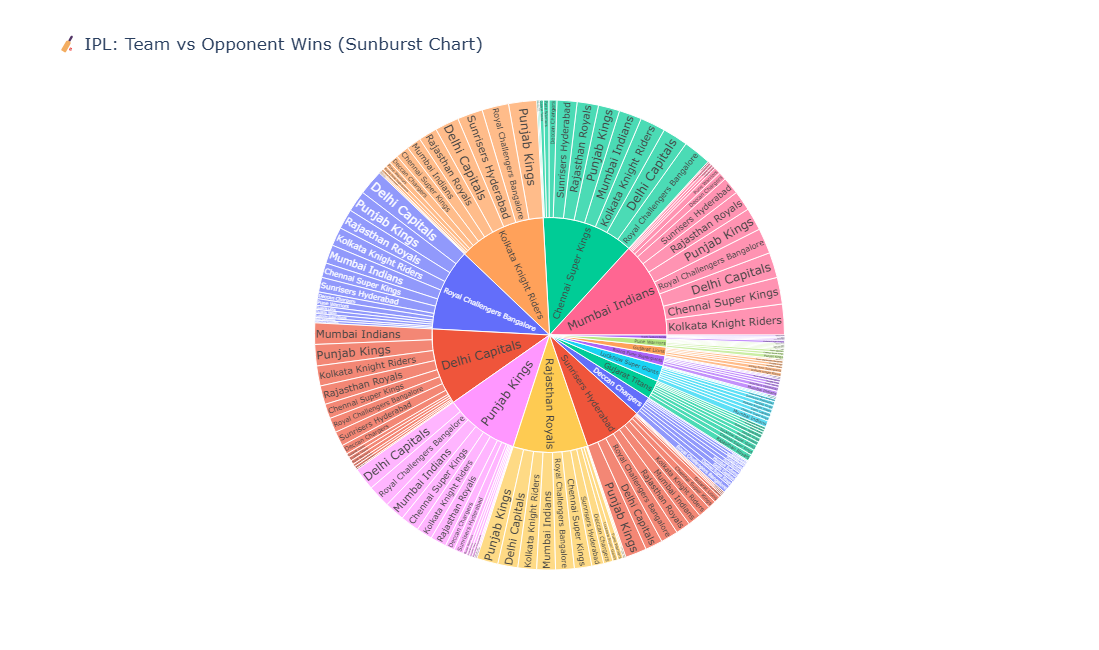

In [159]:

import pandas as pd
import plotly.express as px

# ✅ Step 1: Load your IPL matches data
matches = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")

# ✅ Step 2: Drop rows with missing winner values
matches_cleaned = matches.dropna(subset=['winner'])

# ✅ Step 3: Define the opponent (team that was not the winner)
def get_opponent(row):
    if row['team1'] == row['winner']:
        return row['team2']
    elif row['team2'] == row['winner']:
        return row['team1']
    else:
        return None  # Shouldn't happen if winner is either team1 or team2

matches_cleaned['opponent'] = matches_cleaned.apply(get_opponent, axis=1)

# ✅ Step 4: Group by Winner and Opponent to count wins
team_vs_opponent = matches_cleaned.groupby(['winner', 'opponent']).size().reset_index(name='wins')

# ✅ Step 5: Create the Sunburst Chart
fig = px.sunburst(
    team_vs_opponent,
    path=['winner', 'opponent'],
    values='wins',
    color='winner',
    title='🏏 IPL: Team vs Opponent Wins (Sunburst Chart)',
    height=650
)

fig.show()

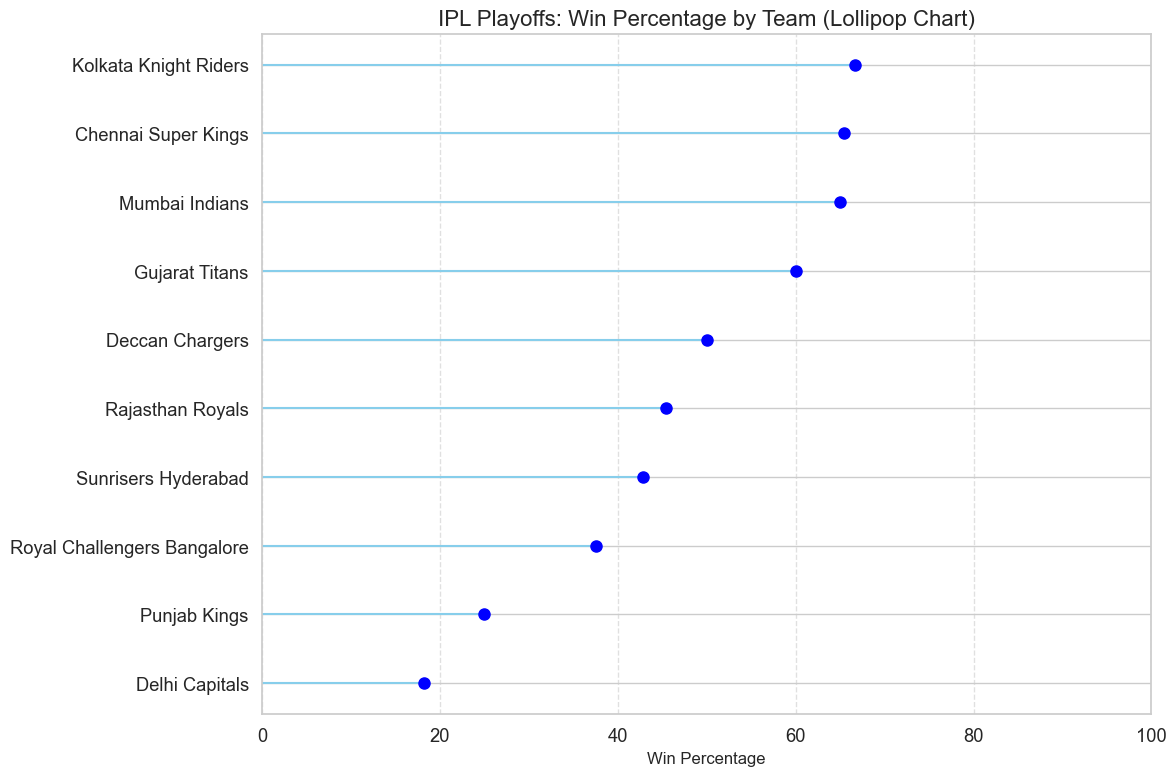

In [161]:
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Load your data
matches_df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")

# ✅ Classify match stage
matches_df['Stage'] = matches_df['match_type'].apply(
    lambda x: 'League' if str(x).strip().lower() == 'league' else 'Playoff'
)

# ✅ Filter only playoff matches
playoff_matches = matches_df[matches_df['Stage'] == 'Playoff']

# ✅ Calculate wins per team
wins_df = playoff_matches['winner'].value_counts().reset_index()
wins_df.columns = ['Team', 'Wins']

# ✅ Calculate playoff appearances per team
appearances_df = pd.concat([
    playoff_matches[['team1']].rename(columns={'team1': 'Team'}),
    playoff_matches[['team2']].rename(columns={'team2': 'Team'})
])
appearances_df = appearances_df['Team'].value_counts().reset_index()
appearances_df.columns = ['Team', 'Appearances']

# ✅ Merge and compute win percentage
playoff_stats = pd.merge(appearances_df, wins_df, on='Team', how='left').fillna(0)
playoff_stats['Win_Percent'] = (playoff_stats['Wins'] / playoff_stats['Appearances']) * 100

# ✅ Filter for teams with at least 3 playoff appearances
playoff_stats = playoff_stats[playoff_stats['Appearances'] >= 3]

# ✅ Sort for plotting
playoff_stats_sorted = playoff_stats.sort_values(by='Win_Percent', ascending=True)

# ✅ Plot Lollipop Chart
plt.figure(figsize=(12, 8))
plt.hlines(
    y=playoff_stats_sorted['Team'],
    xmin=0,
    xmax=playoff_stats_sorted['Win_Percent'],
    color='skyblue'
)
plt.plot(
    playoff_stats_sorted['Win_Percent'],
    playoff_stats_sorted['Team'],
    "o",
    markersize=8,
    color='blue'
)

# ✅ Formatting
plt.title("IPL Playoffs: Win Percentage by Team (Lollipop Chart)", fontsize=16)
plt.xlabel("Win Percentage", fontsize=12)
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [163]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
import random

# Load the IPL data
matches = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\datavizfp\Updated_Matches.csv")

# IPL Indian city coordinates
city_coords = {
    'Mumbai': (19.0760, 72.8777),
    'Chennai': (13.0827, 80.2707),
    'Delhi': (28.6139, 77.2090),
    'Kolkata': (22.5726, 88.3639),
    'Bangalore': (12.9716, 77.5946),
    'Hyderabad': (17.3850, 78.4867),
    'Ahmedabad': (23.0225, 72.5714),
    'Jaipur': (26.9124, 75.7873),
    'Mohali': (30.7046, 76.7179),
    'Pune': (18.5204, 73.8567),
    'Raipur': (21.2514, 81.6296),
    'Ranchi': (23.3441, 85.3096),
    'Dharamsala': (32.2190, 76.3234),
    'Visakhapatnam': (17.6868, 83.2185),
    'Cuttack': (20.4625, 85.8828),
    'Indore': (22.7196, 75.8577),
    'Nagpur': (21.1458, 79.0882),
}

# Filter to Indian cities only
matches = matches[matches['city'].isin(city_coords.keys())]

# Group by city and winner
team_city_wins = matches.dropna(subset=['winner']).groupby(['city', 'winner']).size().reset_index(name='wins')
team_city_wins['lat'] = team_city_wins['city'].map(lambda x: city_coords[x][0])
team_city_wins['lon'] = team_city_wins['city'].map(lambda x: city_coords[x][1])

# Assign random colors to each team
teams = team_city_wins['winner'].unique()
team_colors = {team: f"#{random.randint(0, 0xFFFFFF):06x}" for team in teams}

# Create map centered on India
india_map = folium.Map(location=[22.9734, 78.6569], zoom_start=5.1, tiles='CartoDB positron')

# Add cluster group to avoid clutter
marker_cluster = MarkerCluster().add_to(india_map)

# Add win bubbles
for _, row in team_city_wins.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=max(3, row['wins'] / 2),
        color=team_colors.get(row['winner'], 'blue'),
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['winner']} - {row['city']}: {row['wins']} wins"
    ).add_to(marker_cluster)

# Save and show
india_map.save("ipl_team_wins_india_map.html")
india_map